# 🎵 Smart Music Recommendation System
An end-to-end ML pipeline that recommends songs based on mood, audio features, and lyrics.
### Built by Mohamed Mazen — AASTMT Computer Engineering student

## 📦 Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')

## 📥 Step 1 — Load Data
Loading and merging two Spotify datasets: a 114k song dataset with genre and popularity metadata, and a 960k song dataset with audio features and lyrics. Merging on artist and song name gives us the richest possible feature set.

In [2]:
def loadData(old_path, new_path):

    df_old = pd.read_csv(old_path)
    df_new = pd.read_csv(new_path)

    print("Old dataset shape:", df_old.shape)
    print("New dataset shape:", df_new.shape)
    print("\nOld columns:", list(df_old.columns))
    print("New columns:", list(df_new.columns))

    return df_old, df_new


df_old, df_new = loadData(
    r"C:\Users\yasmi\Downloads\dataset.csv.zip",
    r"C:\Users\yasmi\Downloads\songs_with_attributes_and_lyrics.csv"
)

Old dataset shape: (114000, 21)
New dataset shape: (955320, 17)

Old columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
New columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics']


## 🧹 Step 2 — Clean & Merge
Cleaning both datasets, standardizing column names, and merging on artist + track name to combine genre, popularity, and lyrics into a single unified dataset.

In [3]:
def cleanData(df_old, df_new):

    df_old = df_old.drop(columns=['Unnamed: 0'], errors='ignore')
    df_old = df_old.drop_duplicates().dropna()
    df_old = df_old[(df_old['duration_ms'] >= 60000) & (df_old['duration_ms'] <= 600000)]

    df_new = df_new.drop_duplicates().dropna(subset=['name', 'artists'])
    df_new = df_new.rename(columns={'name': 'track_name', 'id': 'track_id'})
    df_new['track_name_lower'] = df_new['track_name'].str.lower().str.strip()
    df_new['artists_lower'] = df_new['artists'].str.lower().str.strip()

    df_old['track_name_lower'] = df_old['track_name'].str.lower().str.strip()
    df_old['artists_lower'] = df_old['artists'].str.lower().str.strip()

    merge_cols = ['track_name_lower', 'artists_lower']
    old_meta = df_old[merge_cols + ['popularity', 'track_genre']].drop_duplicates(subset=merge_cols)

    df_merged = df_new.merge(old_meta, on=merge_cols, how='left')

    df_merged['popularity'] = df_merged['popularity'].fillna(df_merged['popularity'].median())
    df_merged['track_genre'] = df_merged['track_genre'].fillna('unknown')

    df_merged = df_merged.drop(columns=['track_name_lower', 'artists_lower'])

    print(f"Merged dataset shape: {df_merged.shape}")
    print(f"Songs with genre: {(df_merged['track_genre'] != 'unknown').sum():,}")
    print(f"Songs with lyrics: {df_merged['lyrics'].notna().sum():,}")
    print(f"Nulls remaining: {df_merged.isnull().sum().sum()}")

    return df_merged


tracks_df = cleanData(df_old, df_new)

Merged dataset shape: (955309, 19)
Songs with genre: 58,688
Songs with lyrics: 955,296
Nulls remaining: 569765


## 🔍 Step 3 — Exploratory Data Analysis
Understanding the data distribution, correlations between audio features, and popularity patterns before building any models.

=== Basic Stats ===
       danceability     energy   loudness  speechiness  acousticness  \
count     955309.00  955309.00  955309.00    955309.00     955309.00   
mean           0.55       0.65      -7.83         0.08          0.28   
std            0.17       0.24       3.79         0.09          0.31   
min            0.00       0.00     -60.00         0.00          0.00   
25%            0.44       0.48      -9.75         0.03          0.01   
50%            0.56       0.69      -7.04         0.05          0.14   
75%            0.68       0.86      -5.15         0.09          0.52   
max            0.99       1.00       4.88         0.97          1.00   

       instrumentalness   liveness    valence      tempo  duration_ms  \
count         955309.00  955309.00  955309.00  955309.00    955309.00   
mean               0.08       0.22       0.49     122.23    234144.33   
std                0.21       0.20       0.25      29.54     90683.75   
min                0.00       0.00     

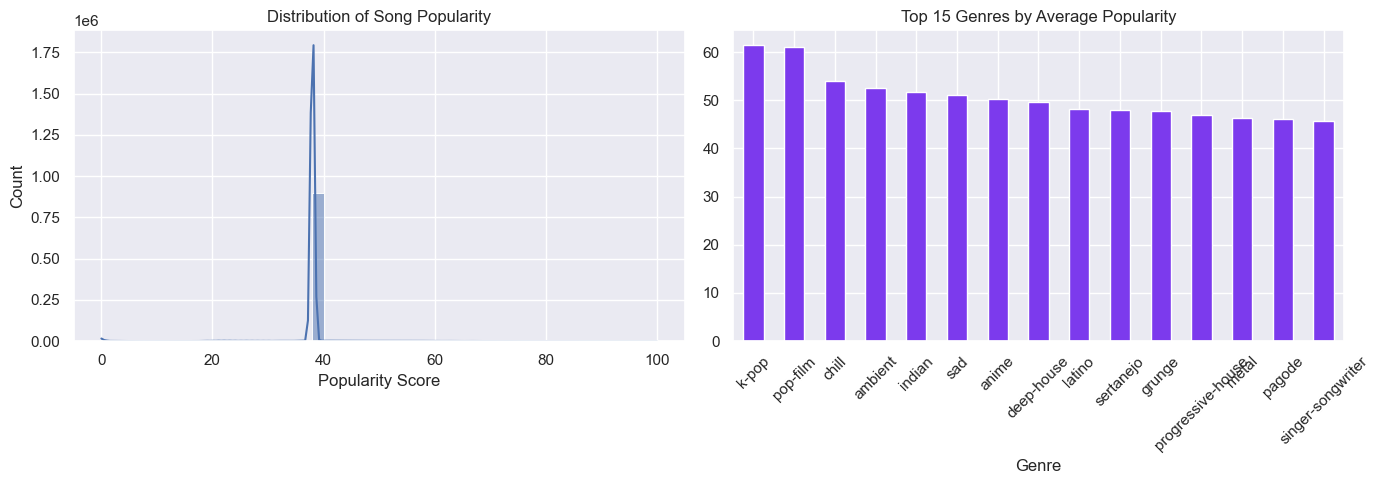

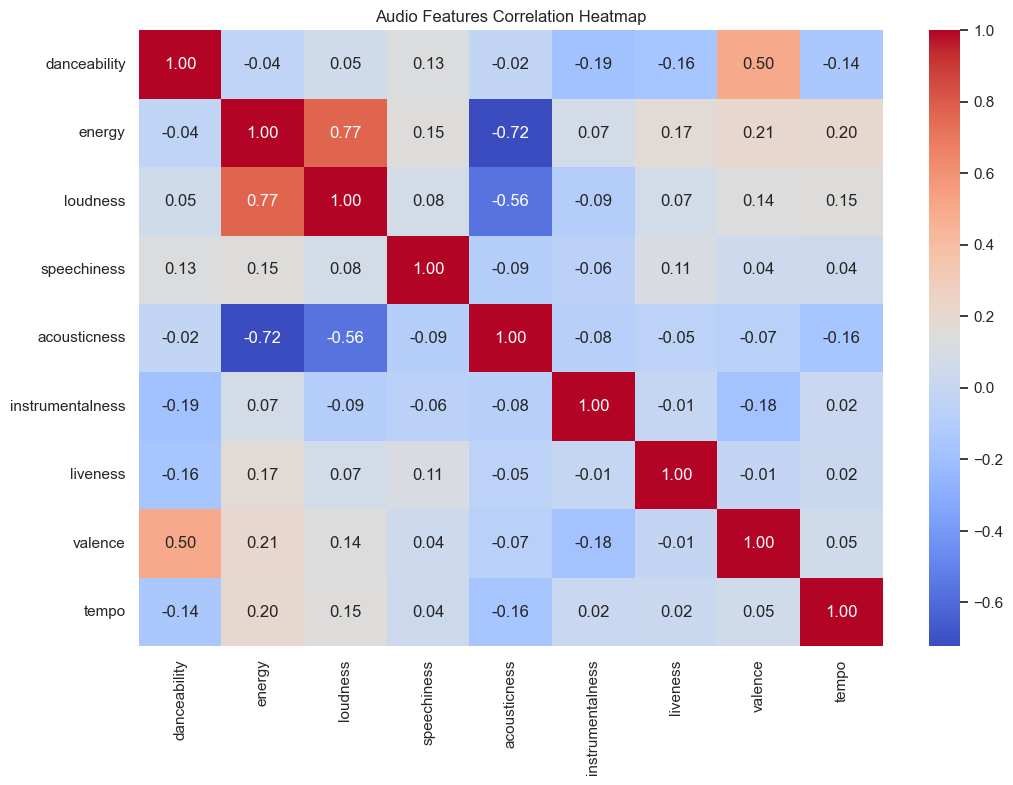

In [4]:
def exploreData(tracks_df):

    print("=== Basic Stats ===")
    print(tracks_df.describe().round(2))

    print(f"\nTotal songs: {len(tracks_df):,}")
    print(f"Unique artists: {tracks_df['artists'].nunique():,}")
    print(f"Unique genres: {tracks_df['track_genre'].nunique()}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(tracks_df['popularity'], bins=50, kde=True, ax=axes[0])
    axes[0].set_title('Distribution of Song Popularity')
    axes[0].set_xlabel('Popularity Score')

    genre_pop = tracks_df[tracks_df['track_genre'] != 'unknown']\
        .groupby('track_genre')['popularity'].mean().nlargest(15)
    genre_pop.plot(kind='bar', ax=axes[1], color='#7c3aed')
    axes[1].set_title('Top 15 Genres by Average Popularity')
    axes[1].set_xlabel('Genre')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    plt.figure(figsize=(12, 8))
    sns.heatmap(tracks_df[audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Audio Features Correlation Heatmap')
    plt.show()


exploreData(tracks_df)

## ⚙️ Step 4 — Feature Engineering
Normalizing audio features to a 0–1 scale so no single feature dominates the model, and assigning mood labels to each song based on the valence/energy model used in music psychology.

In [5]:
def normalizeFeatures(tracks_df):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    scaler = MinMaxScaler()
    tracks_df[audio_features] = scaler.fit_transform(tracks_df[audio_features])

    print("Features normalized ✅")
    print(tracks_df[['danceability', 'energy', 'tempo', 'loudness']].describe().round(2))
    return tracks_df


tracks_df = normalizeFeatures(tracks_df)

Features normalized ✅
       danceability     energy      tempo   loudness
count     955309.00  955309.00  955309.00  955309.00
mean           0.55       0.65       0.50       0.80
std            0.17       0.24       0.12       0.06
min            0.00       0.00       0.00       0.00
25%            0.44       0.48       0.40       0.77
50%            0.56       0.69       0.49       0.82
75%            0.68       0.86       0.57       0.85
max            1.00       1.00       1.00       1.00


In [6]:
def createMoodScore(tracks_df):

    def getMood(row):
        if row['valence'] >= 0.5 and row['energy'] >= 0.5:
            return 'happy'
        elif row['valence'] >= 0.5 and row['energy'] < 0.5:
            return 'calm'
        elif row['valence'] < 0.5 and row['energy'] >= 0.5:
            return 'angry'
        else:
            return 'sad'

    tracks_df['mood'] = tracks_df.apply(getMood, axis=1)
    print(tracks_df['mood'].value_counts())
    return tracks_df


tracks_df = createMoodScore(tracks_df)

mood
happy    375557
angry    322560
sad      181791
calm      75401
Name: count, dtype: int64


## 🎯 Step 5 — Song Clustering
Using KMeans unsupervised learning to group songs into natural vibes. The Elbow Method helps us find the optimal number of clusters, and PCA reduces the 9-dimensional feature space to 2D for visualization.

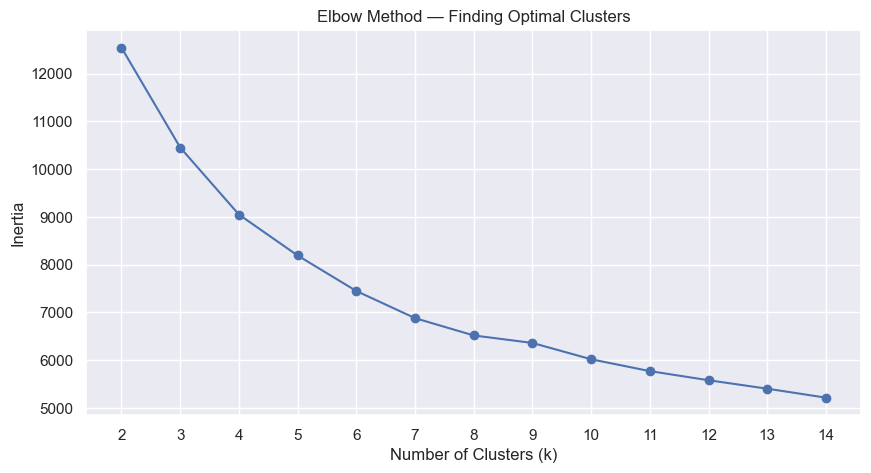

In [7]:
def findOptimalClusters(tracks_df):

    sample_df = tracks_df.sample(n=50000, random_state=42)

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    inertias = []
    k_range = range(2, 15)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
        kmeans.fit(sample_df[audio_features])
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 5))
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method — Finding Optimal Clusters')
    plt.xticks(k_range)
    plt.show()


findOptimalClusters(tracks_df)
# Elbow appears at k=5 — rerunning with optimal clusters

In [8]:
def clusterSongs(tracks_df, n_clusters=5):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=3)
    tracks_df['cluster'] = kmeans.fit_predict(tracks_df[audio_features])

    print(f"Songs grouped into {n_clusters} clusters ✅")
    print(tracks_df['cluster'].value_counts())
    return tracks_df, kmeans


tracks_df, kmeans = clusterSongs(tracks_df, n_clusters=5)

Songs grouped into 5 clusters ✅
cluster
0    287900
4    276804
1    165700
2    153915
3     70990
Name: count, dtype: int64


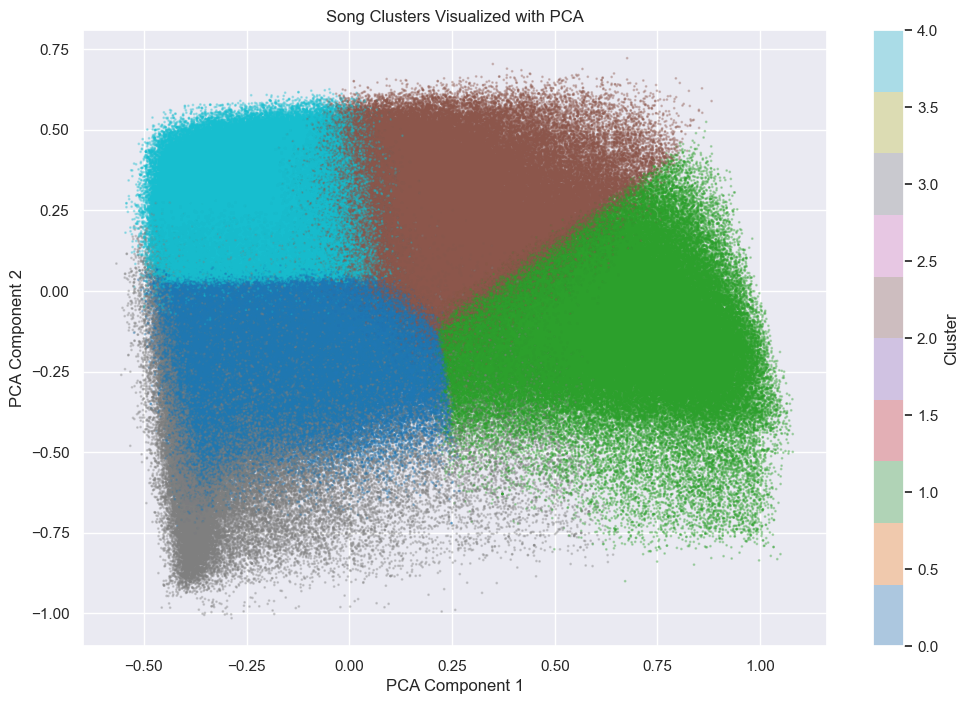

Variance explained: 60.85%


In [9]:
def visualizeClusters(tracks_df):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(tracks_df[audio_features])

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                          c=tracks_df['cluster'], cmap='tab10', alpha=0.3, s=1)
    plt.colorbar(scatter, label='Cluster')
    plt.title('Song Clusters Visualized with PCA')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

    print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")


visualizeClusters(tracks_df)

In [18]:
def labelClusters(tracks_df):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    print(tracks_df.groupby('cluster')[audio_features].mean().round(2))

    cluster_names = {
    0: 'Intense',
    1: 'Sad/Acoustic',
    2: 'Chill',
    3: 'Instrumental',
    4: 'Party'
    }

    tracks_df['vibe'] = tracks_df['cluster'].map(cluster_names)
    print("\n", tracks_df['vibe'].value_counts())
    return tracks_df


tracks_df = labelClusters(tracks_df)

         danceability  energy  loudness  speechiness  acousticness  \
cluster                                                              
0                0.48    0.76      0.83         0.09          0.07   
1                0.47    0.30      0.74         0.05          0.77   
2                0.64    0.57      0.79         0.10          0.57   
3                0.45    0.78      0.81         0.08          0.09   
4                0.66    0.76      0.82         0.10          0.11   

         instrumentalness  liveness  valence  tempo  
cluster                                              
0                    0.03      0.26     0.32   0.52  
1                    0.07      0.18     0.29   0.46  
2                    0.02      0.24     0.67   0.48  
3                    0.72      0.23     0.34   0.51  
4                    0.02      0.19     0.72   0.50  

 vibe
Intense         287900
Party           276804
Sad/Acoustic    165700
Chill           153915
Instrumental     70990
Name: cou

## 🤖 Step 6 — Can we predict the next hit?
Training three classifiers to predict whether a song will be popular based on its audio features alone. A song is defined as popular if its Spotify popularity score exceeds 50.

In [11]:
def createTarget(tracks_df):

    tracks_df['is_popular'] = (tracks_df['popularity'] >= 50).astype(int)

    print("=== Target Distribution ===")
    print(tracks_df['is_popular'].value_counts())
    print(f"\nPopular songs: {tracks_df['is_popular'].mean():.2%}")
    return tracks_df


tracks_df = createTarget(tracks_df)

=== Target Distribution ===
is_popular
0    939299
1     16010
Name: count, dtype: int64

Popular songs: 1.68%


In [33]:
def trainModels(tracks_df):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    X = tracks_df[audio_features]
    y = tracks_df['is_popular']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Training set: {X_train.shape[0]:,} songs")
    print(f"Testing set: {X_test.shape[0]:,} songs")

    models = {
        'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
        'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
        'XGBoost': XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss')
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"\n=== {name} ===")
        print(classification_report(y_test, y_pred))
        results[name] = model

    return results, X_test, y_test


results, X_test, y_test = trainModels(tracks_df)

Training set: 90,839 songs
Testing set: 22,710 songs

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.54      0.64     16841
           1       0.32      0.62      0.42      5869

    accuracy                           0.56     22710
   macro avg       0.56      0.58      0.53     22710
weighted avg       0.68      0.56      0.58     22710


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     16841
           1       0.87      0.48      0.62      5869

    accuracy                           0.85     22710
   macro avg       0.85      0.73      0.76     22710
weighted avg       0.85      0.85      0.83     22710


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.63      0.73     16841
           1       0.40      0.71      0.51      5869

    accuracy                           0.65     22710
   mac

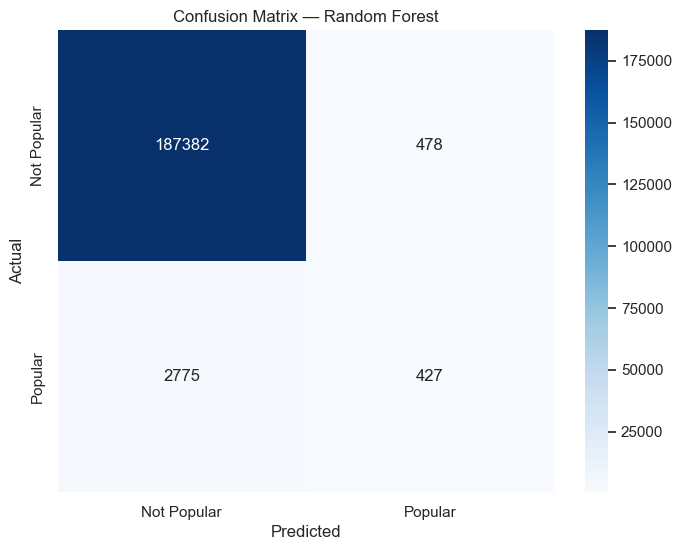

In [13]:
def confusionMatrix(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Popular', 'Popular'],
                yticklabels=['Not Popular', 'Popular'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


confusionMatrix(results['Random Forest'], X_test, y_test, 'Random Forest')

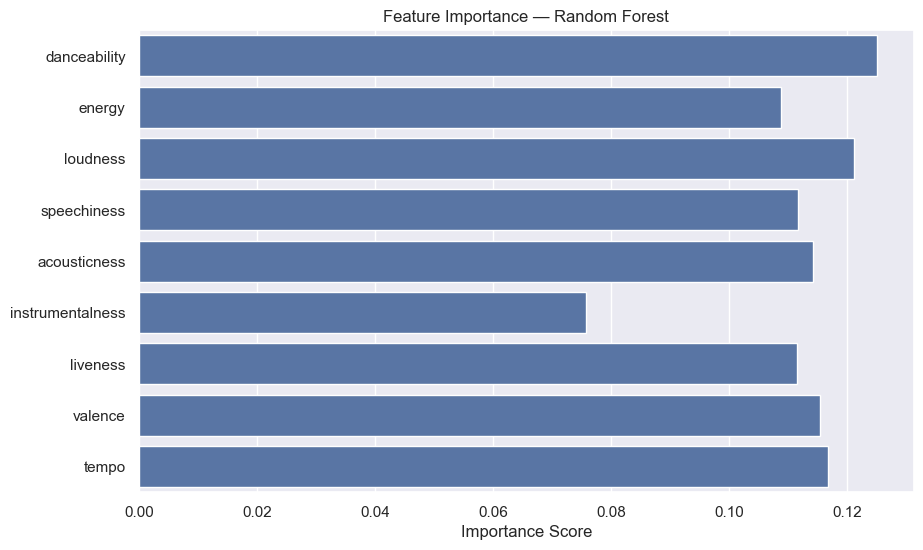

Model saved ✅


In [14]:
def featureImportance(results):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    rf_model = results['Random Forest']
    importance = rf_model.feature_importances_

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance, y=audio_features)
    plt.title('Feature Importance — Random Forest')
    plt.xlabel('Importance Score')
    plt.show()


featureImportance(results)
joblib.dump(results['Random Forest'], 'random_forest_model.pkl')
print("Model saved ✅")

## 🧠 Step 7 — NLP Mood Detection
Using VADER sentiment analysis to detect mood from free-text user input. The compound score maps directly to our four mood categories, enabling natural language interaction with the recommendation system.

In [15]:
def detectMood(user_text):

    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(user_text)
    compound = scores['compound']

    if compound >= 0.5:
        return 'happy'
    elif compound >= 0.0:
        return 'calm'
    elif compound >= -0.5:
        return 'sad'
    else:
        return 'angry'


detectMood("I feel amazing and full of energy today!")

'happy'

## 🎵 Step 8 — Recommendation Engine
Four recommendation modes: by mood detected from text, by genre, by audio similarity to a given song, and by direct search. All search and matching is case-insensitive and uses fuzzy artist matching for robustness.

In [31]:
def recommendByMood(mood, tracks_df, n=10):

    mood_df = tracks_df[tracks_df['mood'] == mood]
    return mood_df.sort_values('popularity', ascending=False)\
                  .drop_duplicates(subset='track_name')\
                  .head(n)[['track_name', 'artists', 'track_genre', 'popularity', 'mood']]


def recommendByGenre(genre, tracks_df, n=10):

    genre_df = tracks_df[tracks_df['track_genre'].str.lower() == genre.lower()]
    return genre_df.sort_values('popularity', ascending=False)\
                   .drop_duplicates(subset='track_name')\
                   .head(n)[['track_name', 'artists', 'mood', 'popularity']]


def getSimilarSongs(song_name, artist_name, tracks_df, n=10):

    audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    song_lower = song_name.lower().strip()
    artist_lower = artist_name.lower().strip()

    mask = (tracks_df['track_name'].str.lower().str.strip() == song_lower) & \
           (tracks_df['artists'].str.lower().str.contains(artist_lower, na=False, regex=False))

    if mask.sum() == 0:
        mask = tracks_df['track_name'].str.lower().str.strip() == song_lower

    if mask.sum() == 0:
        mask = tracks_df['track_name'].str.lower().str.contains(song_lower, na=False, regex=False)

    if mask.sum() == 0:
        print(f"❌ '{song_name}' not found. Try searching first to check the exact title.")
        return None

    song_idx = tracks_df[mask].sort_values('popularity', ascending=False).index[0]
    found_song = tracks_df.loc[song_idx, 'track_name']
    found_artist = tracks_df.loc[song_idx, 'artists']
    print(f"🎵 Finding songs similar to '{found_song}' by {found_artist}...\n")

    features_matrix = tracks_df[audio_features].values
    similarity_scores = cosine_similarity([features_matrix[song_idx]], features_matrix)[0]
    similar_indices = similarity_scores.argsort()[::-1][1:1000]

    results = tracks_df.iloc[similar_indices][['track_name', 'artists', 'track_genre', 'mood', 'popularity']]
    results = results[results['track_name'].str.lower() != song_lower]
    results = results.drop_duplicates(subset='track_name')
    return results.head(n)

def searchSong(query, tracks_df, n=10):

    results = tracks_df[
        tracks_df['track_name'].str.lower().str.contains(query.lower(), na=False) |
        tracks_df['artists'].str.lower().str.contains(query.lower(), na=False)
    ][['track_name', 'artists', 'track_genre', 'mood', 'popularity']]\
    .drop_duplicates(subset='track_name')\
    .sort_values('popularity', ascending=False)\
    .head(n)

    return results if not results.empty else None


def recommendByText(user_text, tracks_df, n=10):

    mood = detectMood(user_text)
    print(f"Detected mood: {mood.upper()} 🎭")
    return recommendByMood(mood, tracks_df, n)


print("Recommendation functions ready ✅")

Recommendation functions ready ✅


## 🖥️ Step 9 — Interactive Interface
A tabbed widget interface for exploring all recommendation features directly inside the notebook.

In [32]:
output = widgets.Output()

header = widgets.HTML("""
<div style='background:linear-gradient(135deg,#7c3aed,#06b6d4);
            padding:20px;border-radius:12px;margin-bottom:15px'>
    <h2 style='color:white;margin:0;font-family:sans-serif'>
        Smart Music Recommendation System 🎵
    </h2>
    <p style='color:rgba(255,255,255,0.8);margin:5px 0 0'>
        Built by Mohamed Mazen — Computer Engineering @ AASTMT
    </p>
</div>
""")

mood_text_input = widgets.Text(
    placeholder='e.g. I feel tired and nostalgic...',
    description='How do you feel:',
    layout=widgets.Layout(width='500px')
)
mood_text_btn = widgets.Button(description='Get Recommendations', button_style='primary', icon='music')

song_input = widgets.Text(placeholder='e.g. Blinding Lights', description='Song Name:', layout=widgets.Layout(width='400px'))
artist_input = widgets.Text(placeholder='e.g. Weeknd', description='Artist:', layout=widgets.Layout(width='400px'))
similar_btn = widgets.Button(description='Find Similar Songs', button_style='primary', icon='search')

search_input = widgets.Text(placeholder='e.g. Cruel Summer', description='Search:', layout=widgets.Layout(width='400px'))
search_btn = widgets.Button(description='Search Songs', button_style='primary', icon='search')

known_genres = sorted([g for g in tracks_df['track_genre'].unique().tolist() if g != 'unknown'])
genre_dropdown = widgets.Dropdown(options=known_genres, description='Genre:', layout=widgets.Layout(width='400px'))
genre_btn = widgets.Button(description='Get Top Songs', button_style='primary', icon='music')


def onMoodText(b):
    with output:
        clear_output()
        text = mood_text_input.value
        if not text:
            print("Please enter how you feel")
            return
        mood = detectMood(text)
        print(f"🎭 Detected mood: {mood.upper()}\n")
        recs = recommendByMood(mood, tracks_df)
        display(recs.reset_index(drop=True))


def onSimilar(b):
    with output:
        clear_output()
        song = song_input.value.strip()
        artist = artist_input.value.strip()
        if not song:
            print("Please enter a song name")
            return
        results = getSimilarSongs(song, artist, tracks_df)
        if results is not None:
            print(f"🎵 Songs similar to '{song}':\n")
            display(results.reset_index(drop=True))
        else:
            print(f"❌ '{song}' not found. Try a different spelling or just the song name.")


def onSearch(b):
    with output:
        clear_output()
        query = search_input.value.strip()
        if not query:
            print("⚠️ Please enter a search term")
            return
        results = searchSong(query, tracks_df)
        if results is not None:
            print(f"🔍 Results for '{query}':\n")
            display(results.reset_index(drop=True))
        else:
            print(f"❌ No results found for '{query}'")


def onGenre(b):
    with output:
        clear_output()
        genre = genre_dropdown.value
        results = recommendByGenre(genre, tracks_df)
        if not results.empty:
            print(f"🎸 Top songs in {genre}:\n")
            display(results.reset_index(drop=True))
        else:
            print(f"❌ No songs found for genre '{genre}'")


mood_text_btn.on_click(onMoodText)
similar_btn.on_click(onSimilar)
search_btn.on_click(onSearch)
genre_btn.on_click(onGenre)

tab1 = widgets.VBox([widgets.HTML("<h4 style='color:#7c3aed'>💬 Recommend by Mood</h4>"), mood_text_input, mood_text_btn])
tab2 = widgets.VBox([widgets.HTML("<h4 style='color:#7c3aed'>🔍 Find Similar Songs</h4>"), song_input, artist_input, similar_btn])
tab3 = widgets.VBox([widgets.HTML("<h4 style='color:#7c3aed'>🔎 Search Songs</h4>"), search_input, search_btn])
tab4 = widgets.VBox([widgets.HTML("<h4 style='color:#7c3aed'>🎸 Browse by Genre</h4>"), genre_dropdown, genre_btn])

tabs = widgets.Tab(children=[tab1, tab2, tab3, tab4])
tabs.set_title(0, '💬 Mood')
tabs.set_title(1, '🔍 Similar')
tabs.set_title(2, '🔎 Search')
tabs.set_title(3, '🎸 Genre')

display(header, tabs, output)

HTML(value="\n<div style='background:linear-gradient(135deg,#7c3aed,#06b6d4);\n            padding:20px;border…

Output()

In [27]:
# Check if The Weeknd is in the new dataset
weeknd = tracks_df[tracks_df['artists'].str.contains('Weeknd', case=False, na=False)]
print(f"Weeknd songs in merged dataset: {len(weeknd)}")
print(weeknd[['track_name', 'artists', 'popularity']].head(10))

Weeknd songs in merged dataset: 75
                                       track_name                   artists  \
3553                            tears in the club      FKA twigs;The Weeknd   
3556                            tears in the club      FKA twigs;The Weeknd   
3557                            tears in the club      FKA twigs;The Weeknd   
3567                            tears in the club      FKA twigs;The Weeknd   
3568                            tears in the club      FKA twigs;The Weeknd   
3578                            tears in the club      FKA twigs;The Weeknd   
3751                                     Odd Look       Kavinsky;The Weeknd   
15071  Make It (feat. The Weeknd) [DJAmg Remixer]     AtariJones;The Weeknd   
17000         Lost in the Fire (feat. The Weeknd)  Gesaffelstein;The Weeknd   
20100                                   You Right       Doja Cat;The Weeknd   

       popularity  
3553            0  
3556            0  
3557            0  
3567           

In [30]:
print(searchSong('cruel summer', tracks_df))
print(searchSong('taylor swift', tracks_df))
print(getSimilarSongs('starboy', 'weeknd', tracks_df))

                           track_name                  artists    track_genre  \
25702                    Cruel Summer               Bananarama          disco   
27041  Cruel Summer Pt.1 - Radio Edit  Dope Ammo;Émilie Rachel  drum-and-bass   

        mood  popularity  
25702  happy          66  
27041  angry          27  
                                        track_name  \
34184                Renegade (feat. Taylor Swift)   
85163  Two Is Better Than One (feat. Taylor Swift)   

                            artists track_genre   mood  popularity  
34184  Big Red Machine;Taylor Swift        folk  happy          69  
85163  Boys Like Girls;Taylor Swift   punk-rock  angry          66  
Song 'starboy' by 'weeknd' not found ❌
None
